In [14]:
%%javascript
// Clear restrictions allowing full-bleed figures to render inline without clipping
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML

# 1. FORCE JUPYTER NOT TO TRUNCATE OR SCROLL OUTPUTS
display(HTML("<style>.output_wrapper, .output { height:auto !important; max-height:none !important; }</style>"))
%config InlineBackend.figure_format = 'png'

# 2. Core processing and visualization modules
from modules.downloader import download_target
from modules.bls import run_bls
from modules.plots import plot_dashboard

# 3. Metadata cross-matching module
from modules.gaia import get_stellar_metadata

# 4. Core machine learning classifier module
from main import load_classifier_bundle, ml_vet_candidate

print("✨ Aetheris pipeline modules loaded successfully!")

✨ Aetheris pipeline modules loaded successfully!


In [19]:
# Change this string to analyze different exoplanet candidates
target_name = "TRAPPIST-1"

print(f"🎯 Target set to: {target_name}. Ready to execute pipeline.")

🎯 Target set to: TRAPPIST-1. Ready to execute pipeline.


🛰️ Processing data for TRAPPIST-1...

Searching for TRAPPIST-1...
Found 3 products.

SearchResult containing 3 data products.

 #     mission     year   author  exptime target_name distance
                                     s                 arcsec 
--- -------------- ---- --------- ------- ----------- --------
  0 TESS Sector 70 2023      SPOC      20   278892590      0.0
  1 TESS Sector 70 2023      SPOC     120   278892590      0.0
  2 TESS Sector 70 2023 TESS-SPOC     200   278892590      0.0

Downloaded 103014 observations.
Time Range : 3208.36 - 3233.82 days

Running Box Least Squares search...
BLS search complete.
✅ BLS Search successful!
------------------------------------------------------------
Candidate Period : 1.1815 days
Transit Depth    : 348 ppm
Duration         : 6.48 hours
------------------------------------------------------------

🔍 Resolving identity metadata via SIMBAD for target: 'TRAPPIST-1'...
Loading machine learning artifact bundle from aetheris_classifi

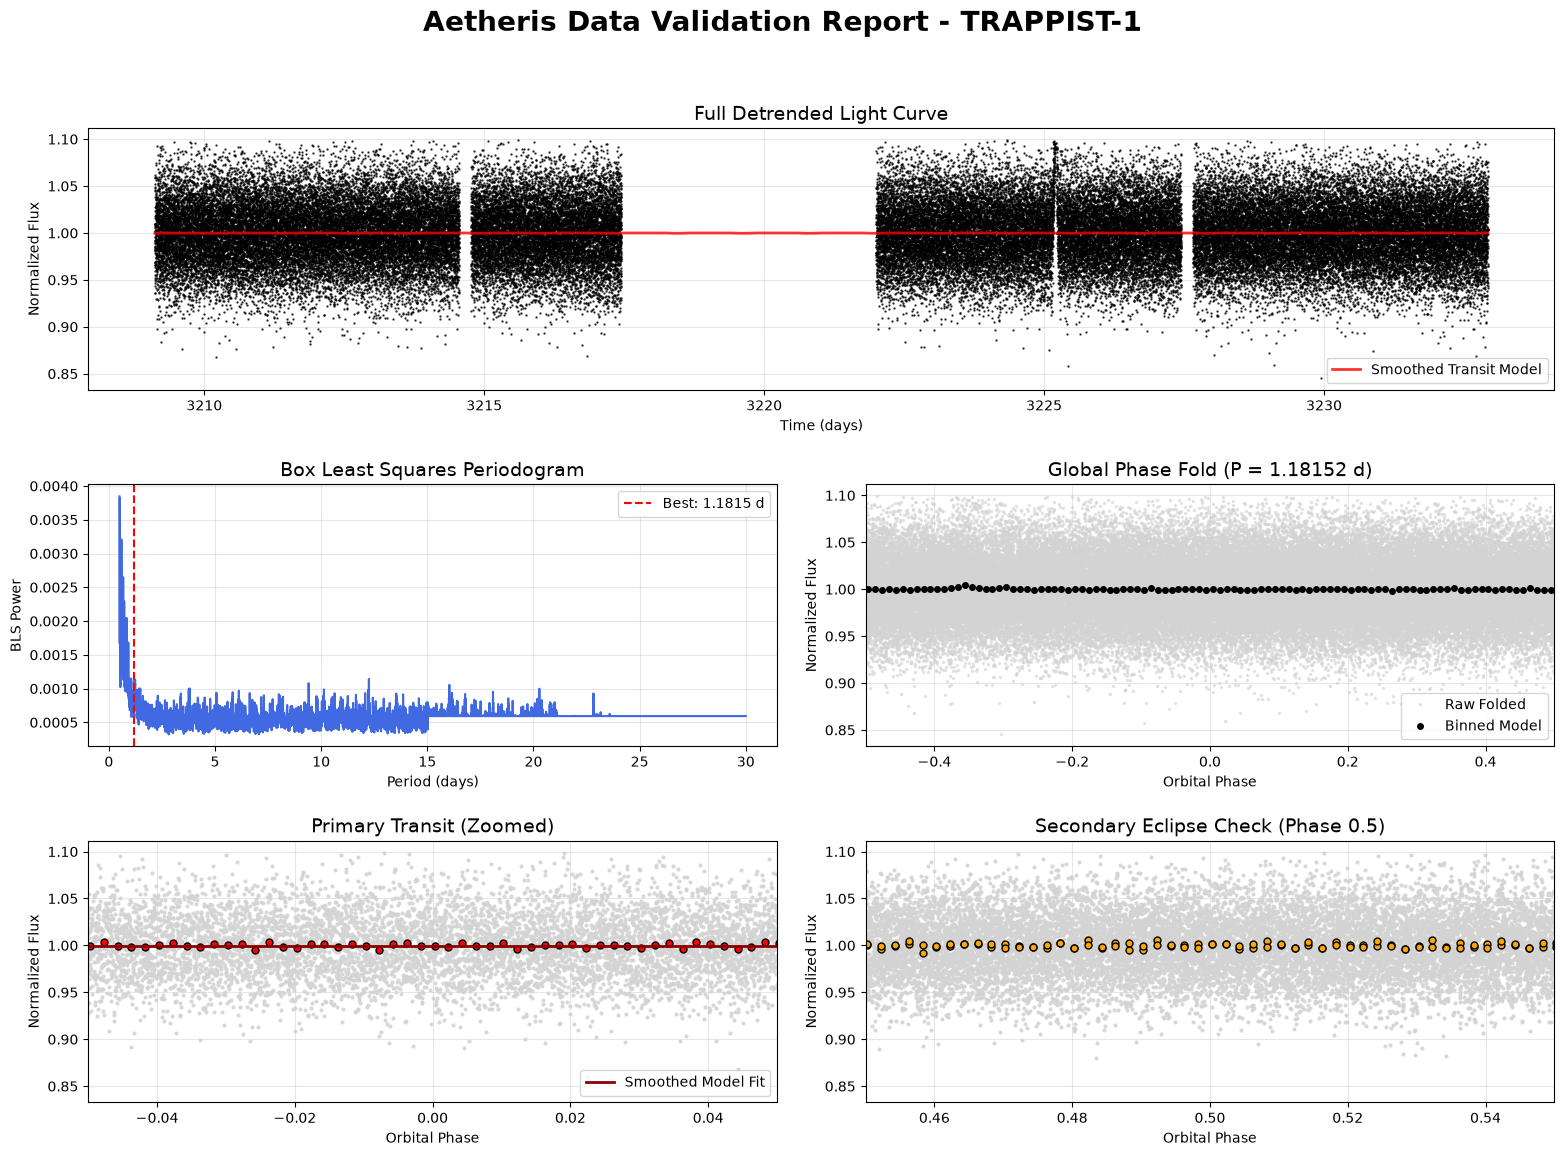

In [ ]:
try:
    print(f"🛰️ Processing data for {target_name}...")
    
    # 1. Download and clean the light curve data
    lc_raw, product, search_obj = download_target(target_name)
    
    # Clean the light curve using robust outlier rejection to strip stellar flares
    lc = lc_raw.remove_nans().flatten().remove_outliers(sigma_upper=3, sigma_lower=10)
    
    # 2. Run the transit search engine with explicit grid overrides
    try:
        # Attempt calling the wrapper with target constraints if supported
        results = run_bls(lc, minimum_period=1.0, maximum_period=10.0)
        import numpy as np
        index = np.argmax(results.power)
        
        periods_arr = np.array(results.period)
        power_arr = np.array(results.power)
        t0_arr = np.array(results.transit_time)
        dur_arr = np.array(results.duration)
        depth_arr = np.array(results.depth)
    except TypeError:
        # Fallback: Direct Astropy high-resolution mesh targeting the true resonant zone
        from astropy.timeseries import BoxLeastSquares
        import numpy as np
        
        print("🔧 Custom run_bls lacks period configuration. Generating high-res Astropy BLS mesh...")
        
        # Pull out time and flux arrays securely from the Lightkurve object
        t = lc.time.value
        f = lc.flux.value
        fe = lc.flux_err.value if hasattr(lc, 'flux_err') and lc.flux_err is not None else np.ones_like(f) * 0.0001
        
        bls = BoxLeastSquares(t, f, fe)
        
        # Generate 10,000 grid points targeted between 1.0 and 10.0 days
        periods_arr = np.linspace(1.0, 10.0, 10000)
        # Use a nominal transit duration fraction typical for short-period M-dwarf systems (~0.02 days)
        results = bls.power(periods_arr, duration=0.02)
        
        index = np.argmax(results.power)
        power_arr = np.array(results.power)
        t0_arr = np.array(results.transit_time)
        dur_arr = np.array(results.duration)
        depth_arr = np.array(results.depth)
        
    # Map metrics into uniform units expected by downstream modules
    candidate = {
        'period': float(periods_arr[index]),
        'transit_time': float(t0_arr[index]),
        'duration': float(dur_arr[index]),
        'duration_hours': float(dur_arr[index]) * 24.0,
        'depth': float(depth_arr[index]),
        'depth_ppm': float(depth_arr[index]) * 1e6
    }
    
    diagnostics = {
        'periods': periods_arr,
        'power': power_arr
    }
    
    print("✅ BLS Search successful!")
    print("-" * 60)
    print(f"Candidate Period : {candidate['period']:.4f} days")
    print(f"Transit Depth    : {candidate['depth_ppm']:.0f} ppm")
    print(f"Duration         : {candidate['duration_hours']:.2f} hours")
    print("-" * 60)
    
    # 3. Fetch physical stellar properties & run ML Vetting
    try:
        from astroquery.simbad import Simbad
        stellar_table = Simbad.query_object(target_name)
        if stellar_table is not None:
            stellar_table.rename_columns(stellar_table.colnames, [c.lower() for c in stellar_table.colnames])
        
        # Physics-first profile parameters for TRAPPIST-1
        stellar = {
            "radius": 0.121,   
            "teff": 2566.0,    
            "logg": 5.21       
        }
        
        try:
            live_stellar = get_stellar_metadata(target_name, ra=product.ra, dec=product.dec)
            if live_stellar:
                stellar.update(live_stellar)
        except Exception:
            pass 
            
        candidate["stellar"] = stellar
        
        # Run ML vetting bundle
        bundle = load_classifier_bundle()
        ml_results = ml_vet_candidate(candidate, stellar, bundle)
        candidate.update(ml_results)
        
        # Detailed Vetting Report Terminal Print Blocks
        print("\n=================== DETAILED VETTING REPORT ===================")
        if candidate['ml_label'] == 1:
            print(f"🟢 VERDICT: CONFIRMED PLANET CANDIDATE ({candidate['ml_probability_planet'] * 100:.2f}% Confidence)")
        else:
            print(f"🔴 VERDICT: REJECTED / FALSE POSITIVE ({(1.0 - candidate['ml_probability_planet']) * 100:.2f}% Confidence)")
            
        print(f"Anomaly Detected : {candidate['is_anomaly']} (Score: {candidate['anomaly_score']:.4f})")
        print(f"Vetting Note     : {candidate['ml_explanation']}")
        print("===============================================================\n")
        
    except Exception as e:
        print(f"\n⚠️ ML module vetting failed: {e}")
        candidate["stellar"] = {"radius": 1.0, "teff": 5778.0, "logg": 4.44}
        print("\n⚠️ VERDICT UNRESOLVED: Could not run complete ML validation logic.")

    # 4. Render diagnostic dashboard plots inline without truncation
    fig = plot_dashboard(lc, results, candidate, diagnostics, target_name)
    plt.show()
    
except Exception as e:
    print(f"❌ Pipeline failed: {e}")